In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop
import pdb

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [2]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20'}, # IFMR
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 6416 - Execution Date: 07-08-2025 17:00:11


################################ Settings #################################
 6419 - # reading default parameters from
 6424 - default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 6428 - # read configuration from 
 6430 - config_file = '/u/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 6433 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1619387000,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
     

Then, run the specific sightline you want

In [13]:
_ = sp_mod.process_location(-3.0, 4.0, # first, enter l and b in degrees
                            solid_angle=1e-2, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing



############################# update location #############################
 113405 - # set location to: 
 113406 - l, b = (-3.00 deg, 4.00 deg)
 113413 - # set solid_angle to:
 113415 - solid_angle = 1.000e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 116463 - # From density profile (number density)
 116466 - expected_total_iMass = 1102975.3819
 116468 - expected_total_eMass = 601914.0979
 116470 - average_iMass_per_star = 0.5739
 116472 - mass_loss_correction = 0.5457
 116474 - n_expected_stars = 1922008.7477
 116479 - # Determine velocities when position are generated 


  0%|          | 0/1922193 [00:00<?, ?it/s]

 160059 - # From Generated Field:
 160061 - generated_stars = 1922193
 160095 - generated_total_iMass = 1104935.8891
 160214 - generated_total_eMass = 603053.6705
 160261 - det_mass_loss_corr = 0.5458
 163055 - # Done


# Population 1;  halo -----------------------------------------------------
 163777 - # From density profile (number density)
 163779 - expected_total_iMass = 1930.1640
 163781 - expected_total_eMass = 1014.4194
 163784 - average_iMass_per_star = 0.5739
 163786 - mass_loss_correction = 0.5256
 163788 - n_expected_stars = 3363.4405
 163794 - # Determine velocities when position are generated 
 164000 - # From Generated Field:
 164002 - generated_stars = 3376
 164004 - generated_total_iMass = 1848.5887
 164014 - generated_total_eMass = 1009.7841
 164017 - det_mass_loss_corr = 0.5462
 164109 - # Done


# Population 2;  nsd ------------------------------------------------------
 165713 - # From density profile (number density)
 165715 - expected_total_iMass = 0.0000
 165717

PopSyCLE formatted output saved in synthpop_output/synthpopsycle_l-3.000_b4.000_psc.h5


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [14]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_l-3.000_b4.000_psc.h5", 
                      output_root2 = 'synthpop_test', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 1)

Working on loop ll, bb =  0 0
Working on loop ll, bb =  0 1
Working on loop ll, bb =  0 2
Working on loop ll, bb =  0 3
Working on loop ll, bb =  0 4
Working on loop ll, bb =  1 0
Working on loop ll, bb =  1 1
Working on loop ll, bb =  1 2
Working on loop ll, bb =  1 3
Working on loop ll, bb =  1 4
Working on loop ll, bb =  2 0
Working on loop ll, bb =  2 1
Working on loop ll, bb =  2 2
Working on loop ll, bb =  2 3
Working on loop ll, bb =  2 4
Working on loop ll, bb =  3 0
Working on loop ll, bb =  3 1
Working on loop ll, bb =  3 2
Working on loop ll, bb =  3 3
Working on loop ll, bb =  3 4
Working on loop ll, bb =  4 0
Working on loop ll, bb =  4 1
Working on loop ll, bb =  4 2
Working on loop ll, bb =  4 3
Working on loop ll, bb =  4 4
Candidate events detected:  85
calc_events runtime : 265.811662 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [15]:
synthetic.refine_events(input_root = 'synthpop_test', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  66
Candidate events in survey window:  57
refine_events runtime : 0.244780 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [16]:
t = Table.read('synthpop_test_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [17]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 1
Number of NSs: 0
Number of WDs: 7
Number of stars: 49


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

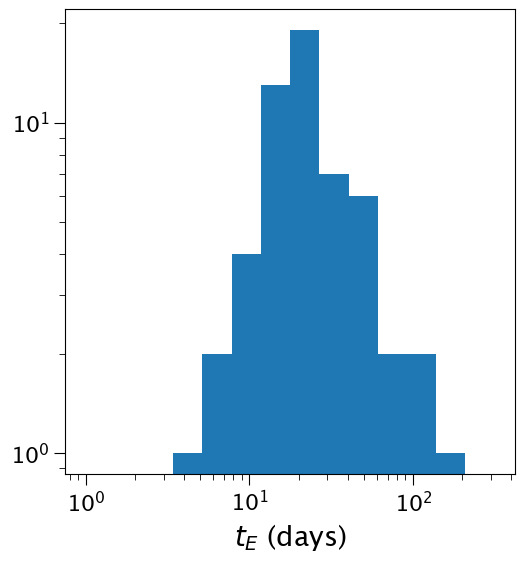

In [18]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

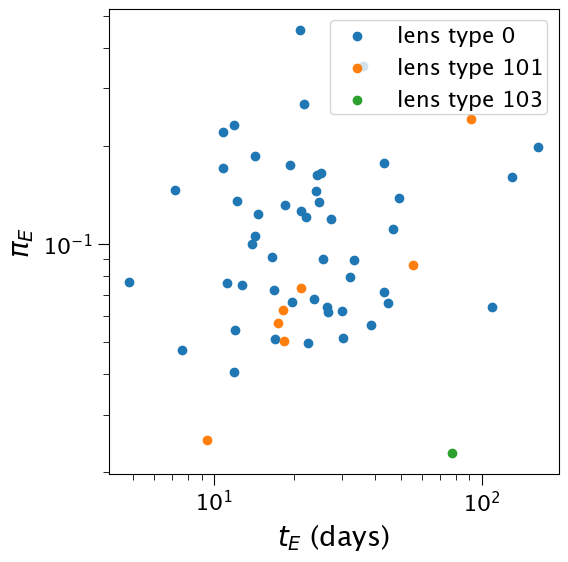

In [19]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label='lens type '+str(rem_id))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend()

## dL vs dS

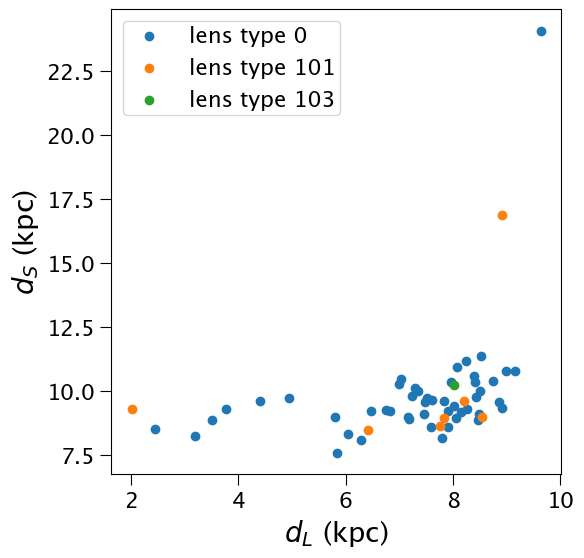

In [21]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()